# Lexical Diversity Analysis Notebook
This notebook builds on the data that exists after running the code in the notebook called 'descriptive stats.ipynb'

### 1. Importing Data
Imports the csv file that was saved at the end of the descriptive_stats notebook. 

NB: If you are using an environment, please remember to choose kernal accordingly

In [17]:
# Import libraries
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import numpy as np
import nltk
from scipy.stats import levene
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
import matplotlib.ticker as mtick
from nltk.tokenize import word_tokenize



# Import CSV file
df_all = pd.read_csv("df_desc_filt.csv", encoding="utf-8")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/nannasteenholdt/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/nannasteenholdt/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_47980/3575113938.py:24: DtypeWarning: Columns (132,134) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv("df_desc_filt.csv", encoding="utf-8")


### 2. Lexical Diversity Analysis

                count      mean       std       min       25%       50%  \
Period_Group                                                              
2022          14617.0  0.556604  0.088704  0.234770  0.494290  0.541547   
2024/2025     10051.0  0.532009  0.078342  0.226082  0.477899  0.518697   

                   75%  max  
Period_Group                 
2022          0.603279  1.0  
2024/2025     0.573980  1.0  


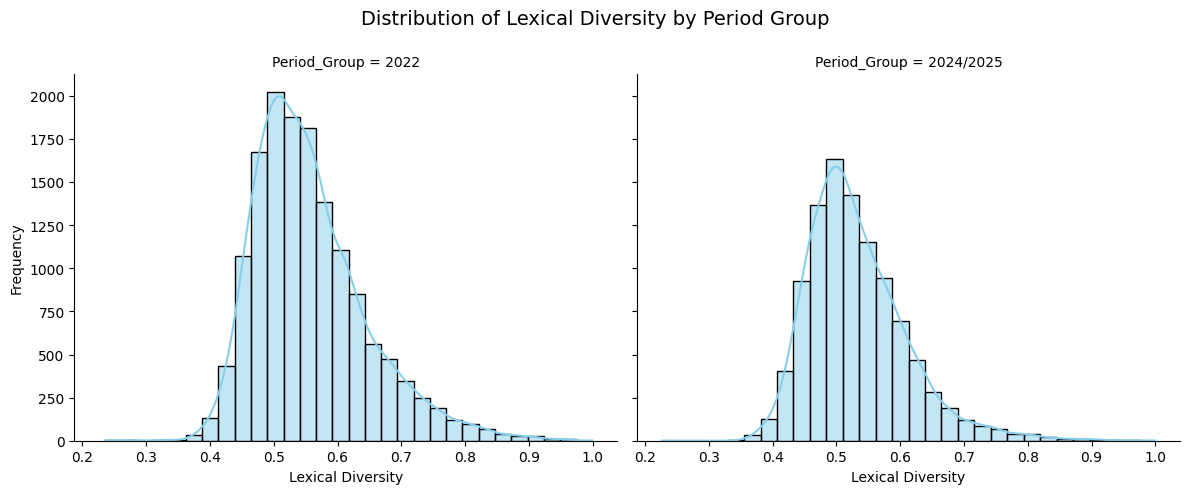

Plot saved to 'plot_outputs/lexical_diversity_distribution_by_period_group.png'


In [18]:
# Create output folder if it doesn't exist
output_plots_dir = "plot_outputs"
os.makedirs(output_plots_dir, exist_ok=True)

# Copy and preprocess
df_ld = df_all.copy() #Renaming df to _ld (lexical diversity) to avoid confusion
df_ld["summary_PostingCreated"] = pd.to_datetime(df_ld["summary_PostingCreated"], errors="coerce").dt.tz_localize(None)
df_ld["Posting_Year"] = df_ld["summary_PostingCreated"].dt.year
df_ld["Period_Group"] = df_ld["Posting_Year"].apply(
    lambda x: "2022" if x == 2022 else ("2024/2025" if x in [2024, 2025] else None)
)

# Filter out NAs from the period group and copy
df_ld_grouped = df_ld[df_ld['Period_Group'].notnull()].copy()

# Compute lexical diversity
def lexical_diversity(text):
    words = word_tokenize(text)
    return len(set(words)) / len(words) if len(words) > 0 else 0

df_ld_grouped['lexical_diversity'] = df_ld_grouped['details_JobPositionPosting_JobPositionInformation_Purpose'].dropna().apply(lexical_diversity)

# Summary statistics
print(df_ld_grouped.groupby('Period_Group')['lexical_diversity'].describe())

# Faceted histogram
g = sns.FacetGrid(
    df_ld_grouped,
    col="Period_Group",
    col_order=["2022", "2024/2025"],
    height=5,
    aspect=1.2,
    sharex=True,
    sharey=True
)
g.map(sns.histplot, "lexical_diversity", bins=30, kde=True, color="skyblue")
g.set_axis_labels("Lexical Diversity", "Frequency")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Distribution of Lexical Diversity by Period Group", fontsize=14)

# Save
output_path = os.path.join(output_plots_dir, "lexical_diversity_distribution_by_period_group.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Plot saved to '{output_path}'")

Creating series to use for statistical tests and some visualisations

In [19]:
# Create separate groups and drop NA's
group_2022 = df_ld_grouped[df_ld_grouped['Period_Group'] == '2022']['lexical_diversity'].dropna()
group_2024_2025 = df_ld_grouped[df_ld_grouped['Period_Group'] == '2024/2025']['lexical_diversity'].dropna()


Checks if there are any 0's.
There should not be any, so remove if there are.

In [20]:
# Check if 0's are present (there shouldn't be any)
print("Ads that have an LD of 0 in 2022:", (group_2022 == 0).sum())
print("Ads that have an LD of 0 in 2024/2025:", (group_2024_2025 == 0).sum())

# # Removes rows with 0's if present
# group_2022 = group_2022[group_2022 > 0]
# group_2024_2025 = group_2024_2025[group_2024_2025 > 0]

Ads that have an LD of 0 in 2022: 0
Ads that have an LD of 0 in 2024/2025: 0


Creating a box plot to visualise the difference between the two periods/groups.

/var/folders/wb/6mdx7sq923sft6mn64xx6b600000gn/T/ipykernel_47980/1301419676.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


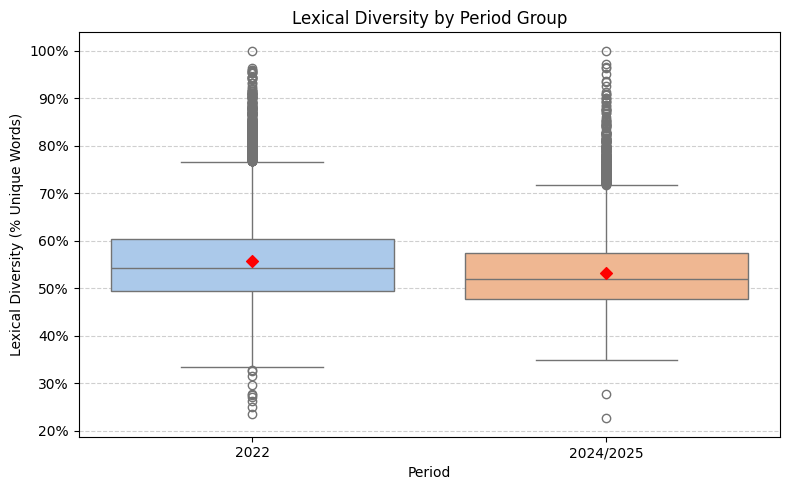

Boxplot saved to: plot_outputs/lexical_diversity_boxplot_by_period_group.png


In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_ld_grouped,
    x='Period_Group',
    y='lexical_diversity',
    order=["2022", "2024/2025"],
    palette='pastel'
)

# Gridlines for readability
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Overlay mean values as red diamonds
means = df_ld_grouped.groupby("Period_Group")["lexical_diversity"].mean()
for i, period in enumerate(["2022", "2024/2025"]):
    plt.scatter(i, means[period], color='red', zorder=10, label='Mean' if i == 0 else "", marker='D')

# Format y-axis as percentage
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.ylabel("Lexical Diversity (% Unique Words)")

# Final touches
plt.title("Lexical Diversity by Period Group")
plt.xlabel("Period")
plt.tight_layout()

# Save
output_dir = "plot_outputs"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "lexical_diversity_boxplot_by_period_group.png")
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Boxplot saved to: {output_path}")

### Q-Q Plots

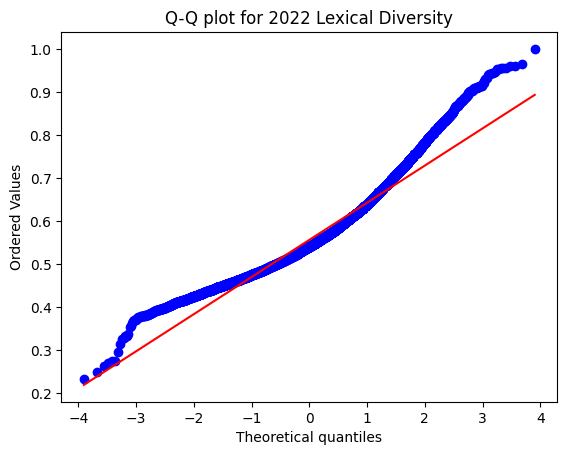

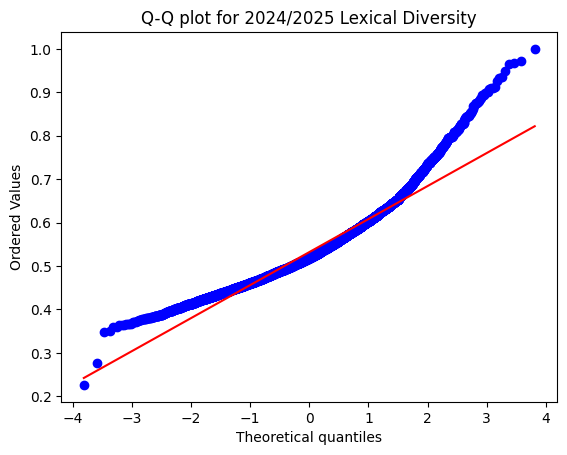

In [22]:
# For 2022
stats.probplot(group_2022, dist="norm", plot=plt)
plt.title("Q-Q plot for 2022 Lexical Diversity")
plt.show()

# For 2024/2025
stats.probplot(group_2024_2025, dist="norm", plot=plt)
plt.title("Q-Q plot for 2024/2025 Lexical Diversity")
plt.show()

Q-Q plot with *log-transformed* lexical diversity values

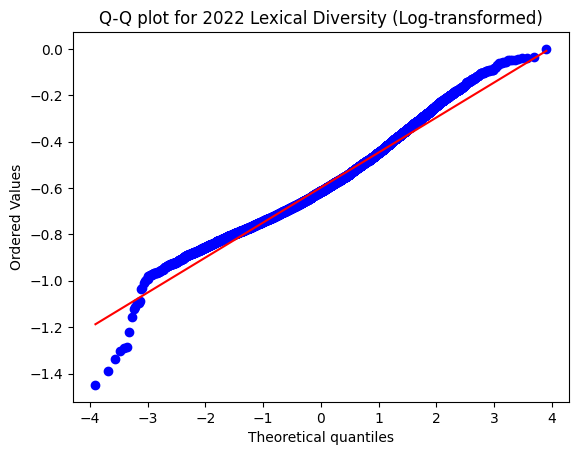

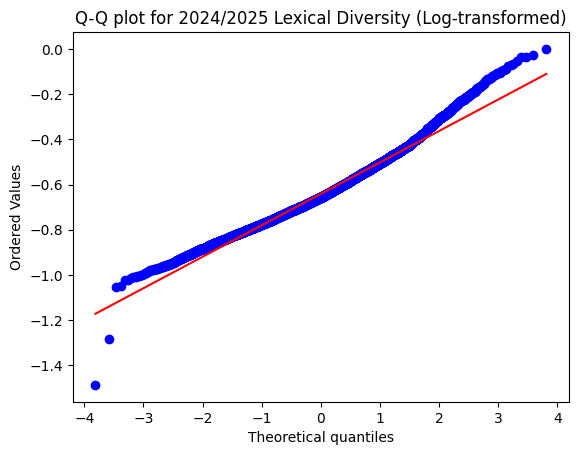

In [23]:
# For 2022
stats.probplot(np.log(group_2022), dist="norm", plot=plt)
plt.title("Q-Q plot for 2022 Lexical Diversity (Log-transformed)")
plt.show()

# For 2024/2025
stats.probplot(np.log(group_2024_2025), dist="norm", plot=plt)
plt.title("Q-Q plot for 2024/2025 Lexical Diversity (Log-transformed)")
plt.show()

### Levene's Test

Using Levene's test for checking homogeneity of variance between the two groups/periods

In [24]:
# Run Levene's test
stat, p_value = levene(group_2022, group_2024_2025)

print(f"Levene's test statistic: {stat:.3f}")
print(f"Levene's test p-value: {p_value:.6f}")

Levene's test statistic: 127.132
Levene's test p-value: 0.000000


Using Levene's test, but with *log-transformed* data

In [25]:
# Run Levene's test WITH LOG
stat, p_value = levene(np.log(group_2022), np.log(group_2024_2025))

print(f"Levene's test statistic (log): {stat:.3f}")
print(f"Levene's test p-value (log): {p_value:.6f}")

Levene's test statistic (log): 68.722
Levene's test p-value (log): 0.000000


### Welsch's T-test

Using Welsch's T-test for comparing groups

In [26]:
# Welsch's T-test
statistic, p_value = ttest_ind(group_2022, group_2024_2025, equal_var=False)

print(f"Welch's t-test statistic: {statistic:.3f}")
print(f"p-value: {p_value:.6f}")

Welch's t-test statistic: 22.945
p-value: 0.000000


Running Welsch's T-test, but on log-transformed data

In [27]:
# Welsch's T-test with log transformation
statistic, p_value = ttest_ind(np.log(group_2022), np.log(group_2024_2025), equal_var=False)

print(f"Welch's t-test statistic (log): {statistic:.3f}")
print(f"p-value (log): {p_value:.6f}")

Welch's t-test statistic (log): 23.033
p-value (log): 0.000000


### Cohen's D (Effect Size)

I use Cohen's D to determine the effect size

In [28]:
# Calculating means
mean_2022 = group_2022.mean()
mean_2024_2025 = group_2024_2025.mean()

# Getting standard deviations
std_2022 = group_2022.std()
std_2024_2025 = group_2024_2025.std()

# Getting sample sizes
n_2022 = len(group_2022)
n_2024_2025 = len(group_2024_2025)

# Getting the pooled standard deviation
pooled_std = np.sqrt(((n_2022 - 1) * std_2022**2 + (n_2024_2025 - 1) * std_2024_2025**2) / (n_2022 + n_2024_2025 - 2))

# Calculating Cohen's d
cohen_d = (mean_2022 - mean_2024_2025) / pooled_std

print(f"Cohen's d: {cohen_d:.3f}")

Cohen's d: 0.291


Finding Cohen's D, but with *log-transformed* data

In [29]:
# Calculating means
mean_2022 = np.log(group_2022).mean()
mean_2024_2025 = np.log(group_2024_2025).mean()

# Getting standard deviations
std_2022 = np.log(group_2022).std()
std_2024_2025 = np.log(group_2024_2025).std()

# Getting sample sizes
n_2022 = len(np.log(group_2022))
n_2024_2025 = len(np.log(group_2024_2025))

# Getting the pooled standard deviation
pooled_std = np.sqrt(((n_2022 - 1) * std_2022**2 + (n_2024_2025 - 1) * std_2024_2025**2) / (n_2022 + n_2024_2025 - 2))

# Calculating Cohen's d
cohen_d = (mean_2022 - mean_2024_2025) / pooled_std

print(f"Cohen's d (log): {cohen_d:.3f}")

Cohen's d (log): 0.294


### Robustness Check

I run a Mann-Whitney U test as a robustness check

In [30]:
# Running Mann-Whitney U test
stat, p = mannwhitneyu(group_2022, group_2024_2025, alternative='two-sided')
print(f"Mann-Whitney U p-value: {p:.6f}")

Mann-Whitney U p-value: 0.000000


Running the Mann-Whitney U with *log-transformed* values

In [31]:
# Running Mann-Whitney U test with log-transformed data
stat, p = mannwhitneyu(np.log(group_2022), np.log(group_2024_2025), alternative='two-sided')
print(f"Mann-Whitney U p-value (log): {p:.6f}")

Mann-Whitney U p-value (log): 0.000000


Since the sample sizes were on the larger side, I make a subset of the dataset and run Welch's T-test again.

In [32]:
# Random subsample (1000 per group)
sampled_2022 = df_ld_grouped[df_ld_grouped["Period_Group"] == "2022"].sample(n=1000, random_state=42)
sampled_2024_2025 = df_ld_grouped[df_ld_grouped["Period_Group"] == "2024/2025"].sample(n=1000, random_state=42)
df_ld_sampled = pd.concat([sampled_2022, sampled_2024_2025])

# Re-run Welch's t-test
group_22 = df_ld_sampled[df_ld_sampled["Period_Group"] == "2022"]["lexical_diversity"]
group_24 = df_ld_sampled[df_ld_sampled["Period_Group"] == "2024/2025"]["lexical_diversity"]
print("Welch's t-test (sampled):", ttest_ind(group_22, group_24, equal_var=False).pvalue)


Welch's t-test (sampled): 1.4517122591756425e-08
